# Layer 22 channel summaries

Продолжение `patch_spread_zigzag_metrics.ipynb` и `patch_success_analysis_soft_metrics.ipynb`: суммарная важность каналов и суммарные дельты на `model.22` для 200 картинок (100 success / 100 fail).

In [1]:
from pathlib import Path
import sys

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import matplotlib.pyplot as plt
import pandas as pd

from patch_success_analysis.channel_metrics import (
    channel_summary_frame,
    compute_or_load_channel_summary,
    plot_channel_summary_grid,
    select_balanced_examples,
)
from patch_success_analysis.notebook_setup import (
    ensure_new_experiments_cwd,
    make_celeb_patch_success_experiment,
)

layer_name = "model.22"
analysis_examples_per_class = 100
force_channel_summary_recompute = False

cwd = ensure_new_experiments_cwd()
attack_config, config, exp = make_celeb_patch_success_experiment(target_layer=layer_name)
cache = exp.build_or_load_cache(force=False)
selected_examples = select_balanced_examples(exp, per_class=analysis_examples_per_class)

print(f"cwd={cwd}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(f"selected={len(selected_examples)} ({analysis_examples_per_class} success / {analysis_examples_per_class} fail)")


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
attack cache key=34df6a12b82dd284
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_34df6a12b82dd284.pkl
selected=200 (100 success / 100 fail)


In [2]:
summary = compute_or_load_channel_summary(
    exp,
    selected_examples,
    layer_name=layer_name,
    force=force_channel_summary_recompute,
)
examples_df = pd.DataFrame(summary["examples"])
display(examples_df.groupby("success")[["drop", "layer_maps_loaded_from_cache"]].agg({
    "drop": ["count", "mean", "std"],
    "layer_maps_loaded_from_cache": "mean",
}))
print(f"channel summary cache: {summary['cache_path']}")
print(f"loaded_from_cache={summary['loaded_from_cache']}")


drop                     layer_maps_loaded_from_cache
        count      mean       std                         mean
success                                                       
False     100  0.082727  0.093692                          1.0
True      100  0.598582  0.179313                          1.0

channel summary cache: new_experiments/outputs/patch_success_analysis/cache/channel_summary_b69f00bc8f4fc0aa.pkl
loaded_from_cache=True


## Unsigned

Importance is `sum(abs(SegmentIG[0;0.1]))` per channel; delta is `sum(abs(patched_activation - clean_activation))` per channel. In the sorted row, both panels use descending unsigned importance order.

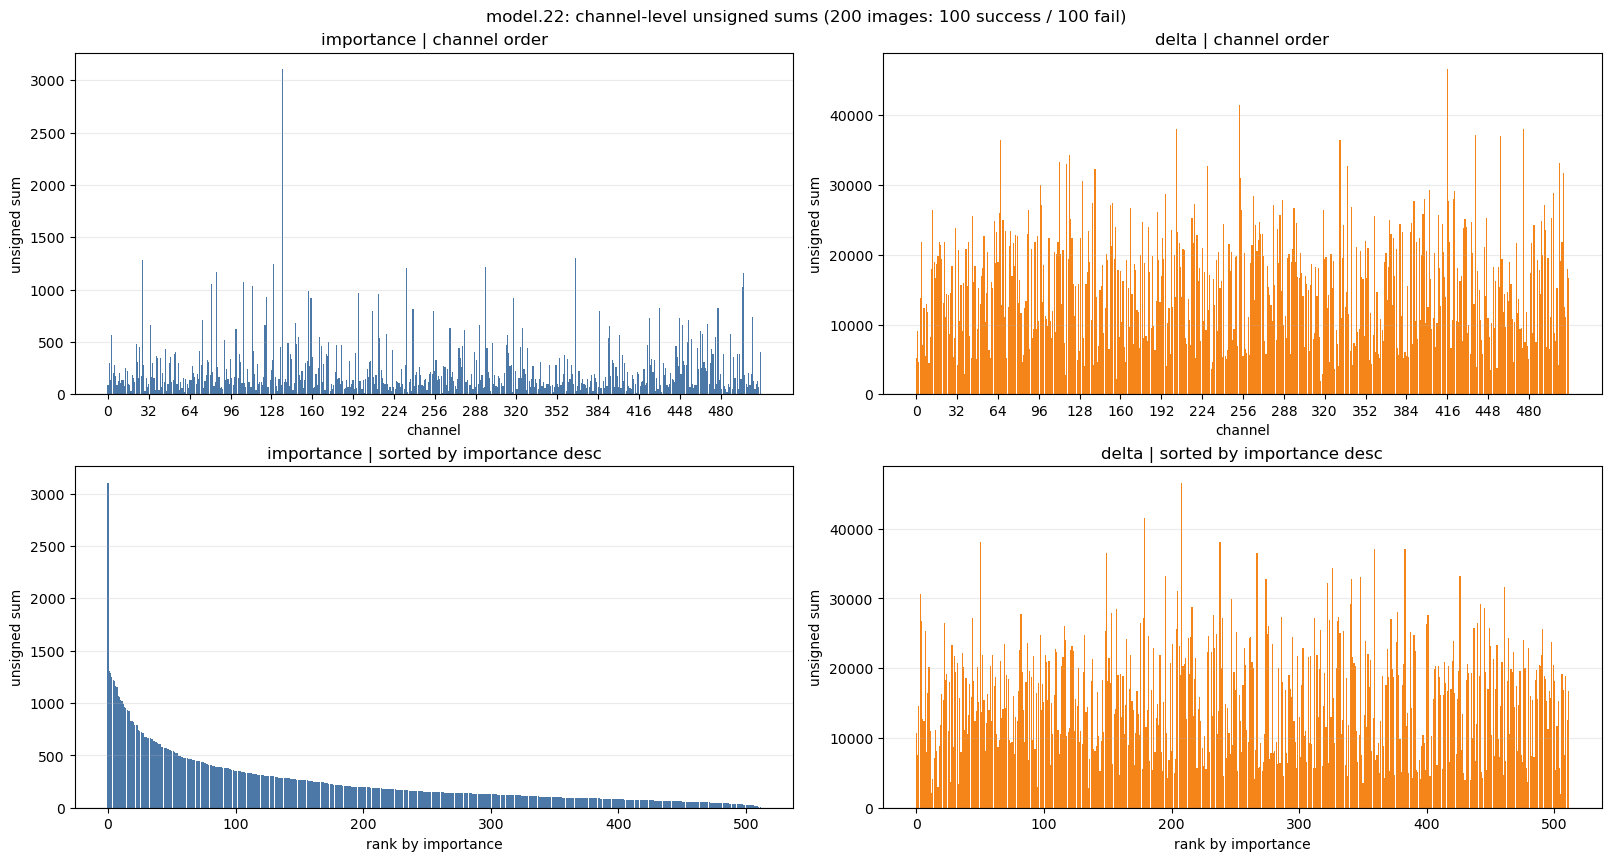

new_experiments/outputs/patch_success_analysis/figures/channel_summary_model_22_unsigned_200.png


,rank,channel,importance_sum,delta_sum
0,1,137,3104.349770,10660.388858
1,2,366,1301.895157,7603.457525
2,3,27,1282.757210,14582.433100
3,4,130,1247.376593,30643.225694
4,5,296,1219.946880,26738.359057
5,6,234,1206.271256,12747.597330
6,7,85,1165.543478,12427.393423
7,8,498,1154.974596,25273.760585
8,9,106,1069.309711,8044.483323
9,10,81,1053.527772,16437.737550


In [3]:
fig = plot_channel_summary_grid(summary, variant="unsigned")
unsigned_fig_path = exp.figures_dir / "channel_summary_model_22_unsigned_200.png"
fig.savefig(unsigned_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(unsigned_fig_path)

unsigned_sorted = channel_summary_frame(summary, variant="unsigned", sorted_by_importance=True)
display(unsigned_sorted.head(20))


## Signed

Importance is `sum(SegmentIG[0;0.1])` per channel; delta is `sum(patched_activation - clean_activation)` per channel. In the sorted row, both panels use descending signed importance order.

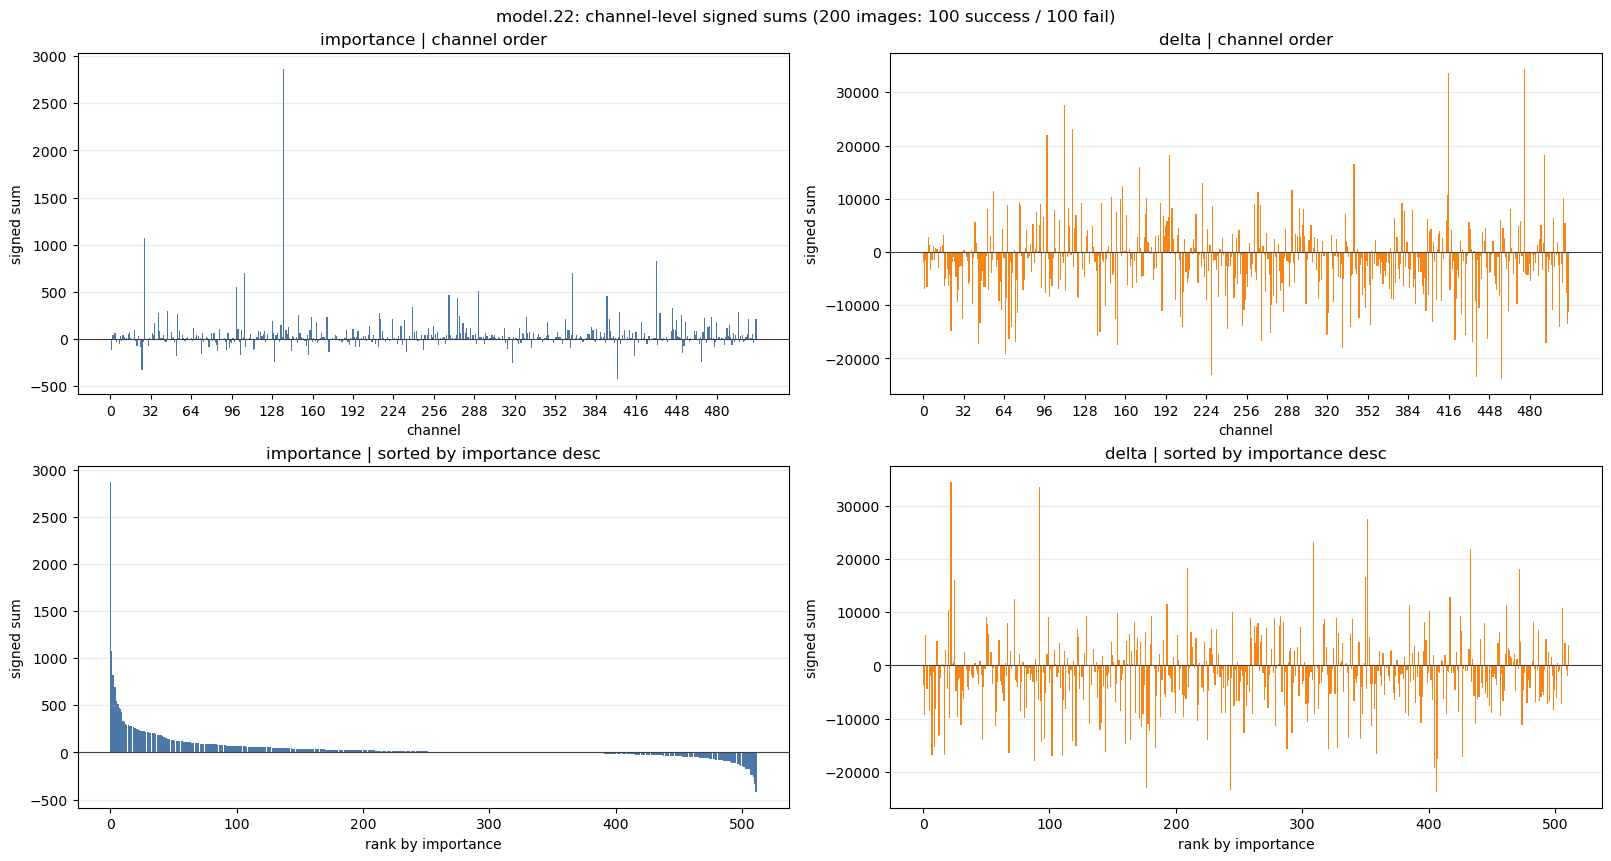

new_experiments/outputs/patch_success_analysis/figures/channel_summary_model_22_signed_200.png


,rank,channel,importance_sum,delta_sum
0,1,137,2868.273594,-3660.618573
1,2,27,1076.498087,-9318.929021
2,3,432,824.955891,5667.296177
3,4,366,699.028676,-4503.807567
4,5,106,696.479050,-159.474906
5,6,100,547.447872,-8506.267341
6,7,291,510.389844,-2051.706136
7,8,268,470.397210,-16773.417570
8,9,393,460.106550,-1144.831122
9,10,275,430.114627,-15242.198476


In [4]:
fig = plot_channel_summary_grid(summary, variant="signed")
signed_fig_path = exp.figures_dir / "channel_summary_model_22_signed_200.png"
fig.savefig(signed_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(signed_fig_path)

signed_sorted = channel_summary_frame(summary, variant="signed", sorted_by_importance=True)
display(signed_sorted.head(20))


## Channel 137 overlays

Канал `137` сильнее всего выделяется в суммарной importance. Ниже берем 5 изображений с максимальной `sum(abs(importance_channel_137))` и накладываем channel map на clean letterboxed image.

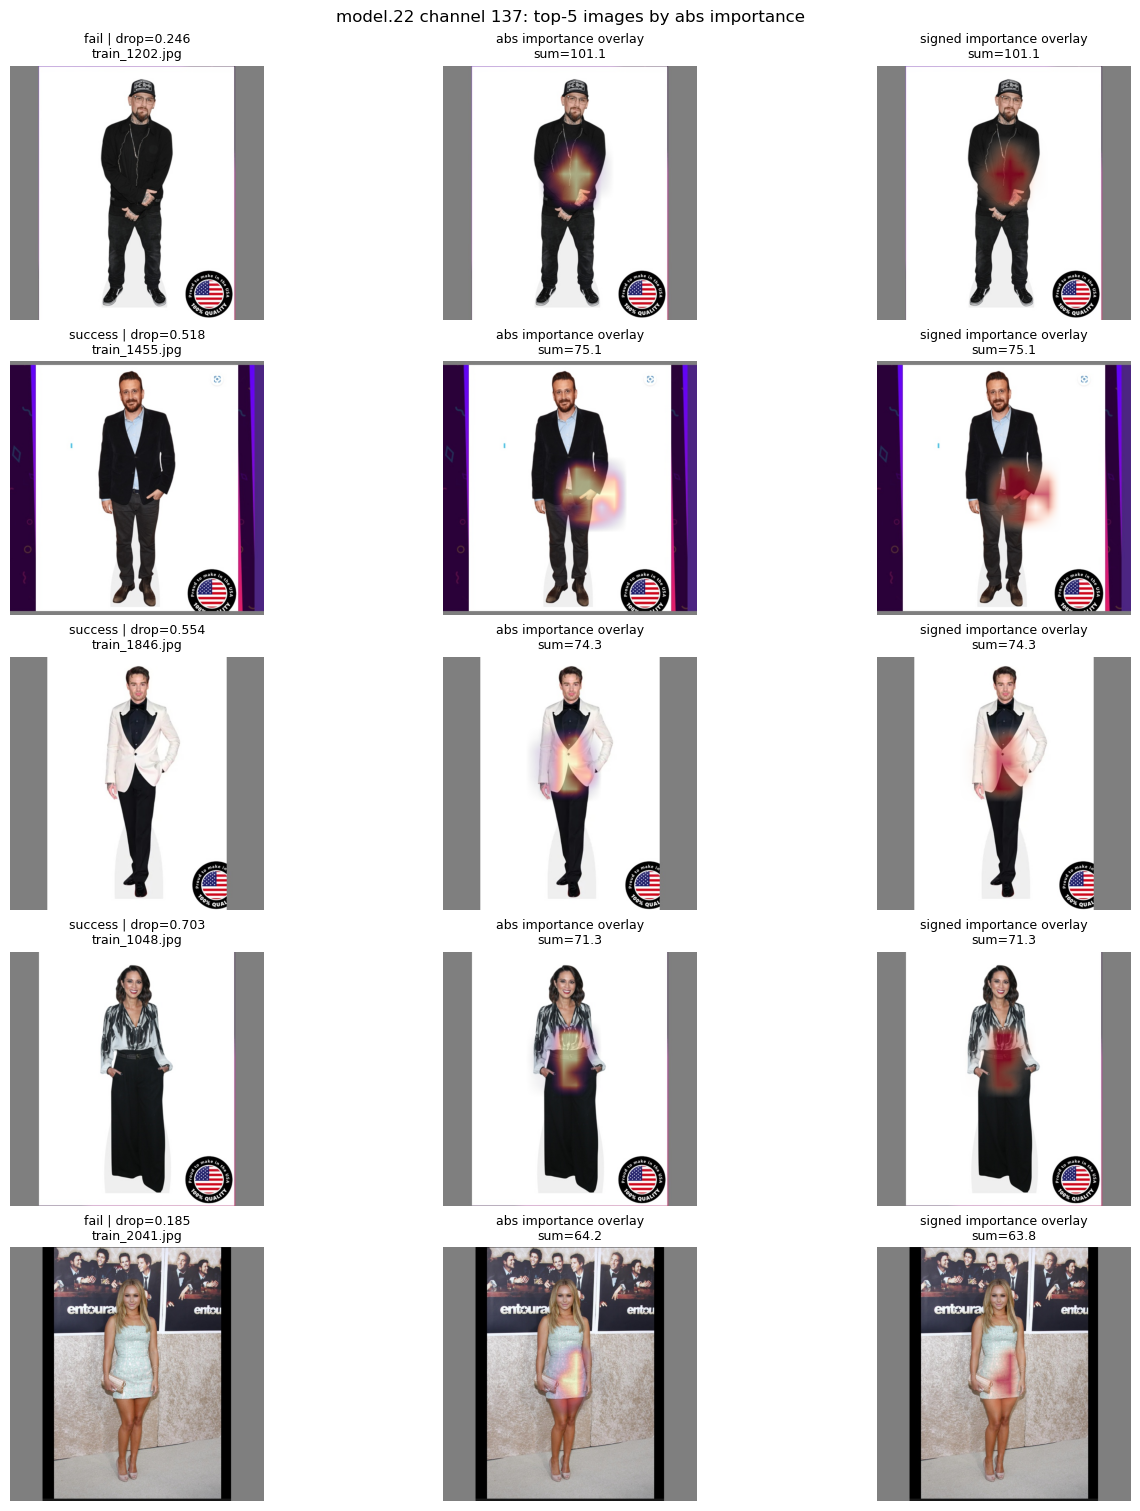

new_experiments/outputs/patch_success_analysis/figures/channel_137_importance_overlay_top5.png


,path,success,drop,channel,importance_abs_sum,importance_signed_sum,delta_abs_sum,delta_signed_sum,layer_maps_cache_path
0,../datasets/celeb_fbi_640/train_1202.jpg,False,0.245795,137,101.074585,101.074585,29.349571,8.550689,new_experiments/outputs/patch_success_analysis...
1,../datasets/celeb_fbi_640/train_1455.jpg,True,0.518465,137,75.113281,75.113281,36.111276,-2.410654,new_experiments/outputs/patch_success_analysis...
2,../datasets/celeb_fbi_640/train_1846.jpg,True,0.554150,137,74.307373,74.307373,40.685990,-2.290214,new_experiments/outputs/patch_success_analysis...
3,../datasets/celeb_fbi_640/train_1048.jpg,True,0.703177,137,71.302368,71.302368,32.268327,5.490201,new_experiments/outputs/patch_success_analysis...
4,../datasets/celeb_fbi_640/train_2041.jpg,False,0.185404,137,64.243164,63.756104,54.715765,5.695418,new_experiments/outputs/patch_success_analysis...


In [5]:
from patch_success_analysis.channel_metrics import plot_channel_importance_overlays

outlier_channel = int(unsigned_sorted.iloc[0]["channel"])
fig, channel137_top5 = plot_channel_importance_overlays(
    exp,
    selected_examples,
    layer_name=layer_name,
    channel=outlier_channel,
    max_examples=5,
)
overlay_fig_path = exp.figures_dir / f"channel_{outlier_channel}_importance_overlay_top5.png"
fig.savefig(overlay_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(overlay_fig_path)
display(channel137_top5)


## Ranked neuron deltas and spiral spread

Дальше работаем уже не с агрегированными каналами, а с нейронами внутри выбранных top-channel subsets: top 1%, top 10% и все каналы. В ranked-neuron графике первые три строки показывают signed delta, следующие три строки показывают `mean(abs(delta))` по примерам для каждого нейрона. Для спирали сверху остаются старые delta-графики со std-заливками, ниже те же delta-кривые без дисперсий плюс importance для того же обхода.

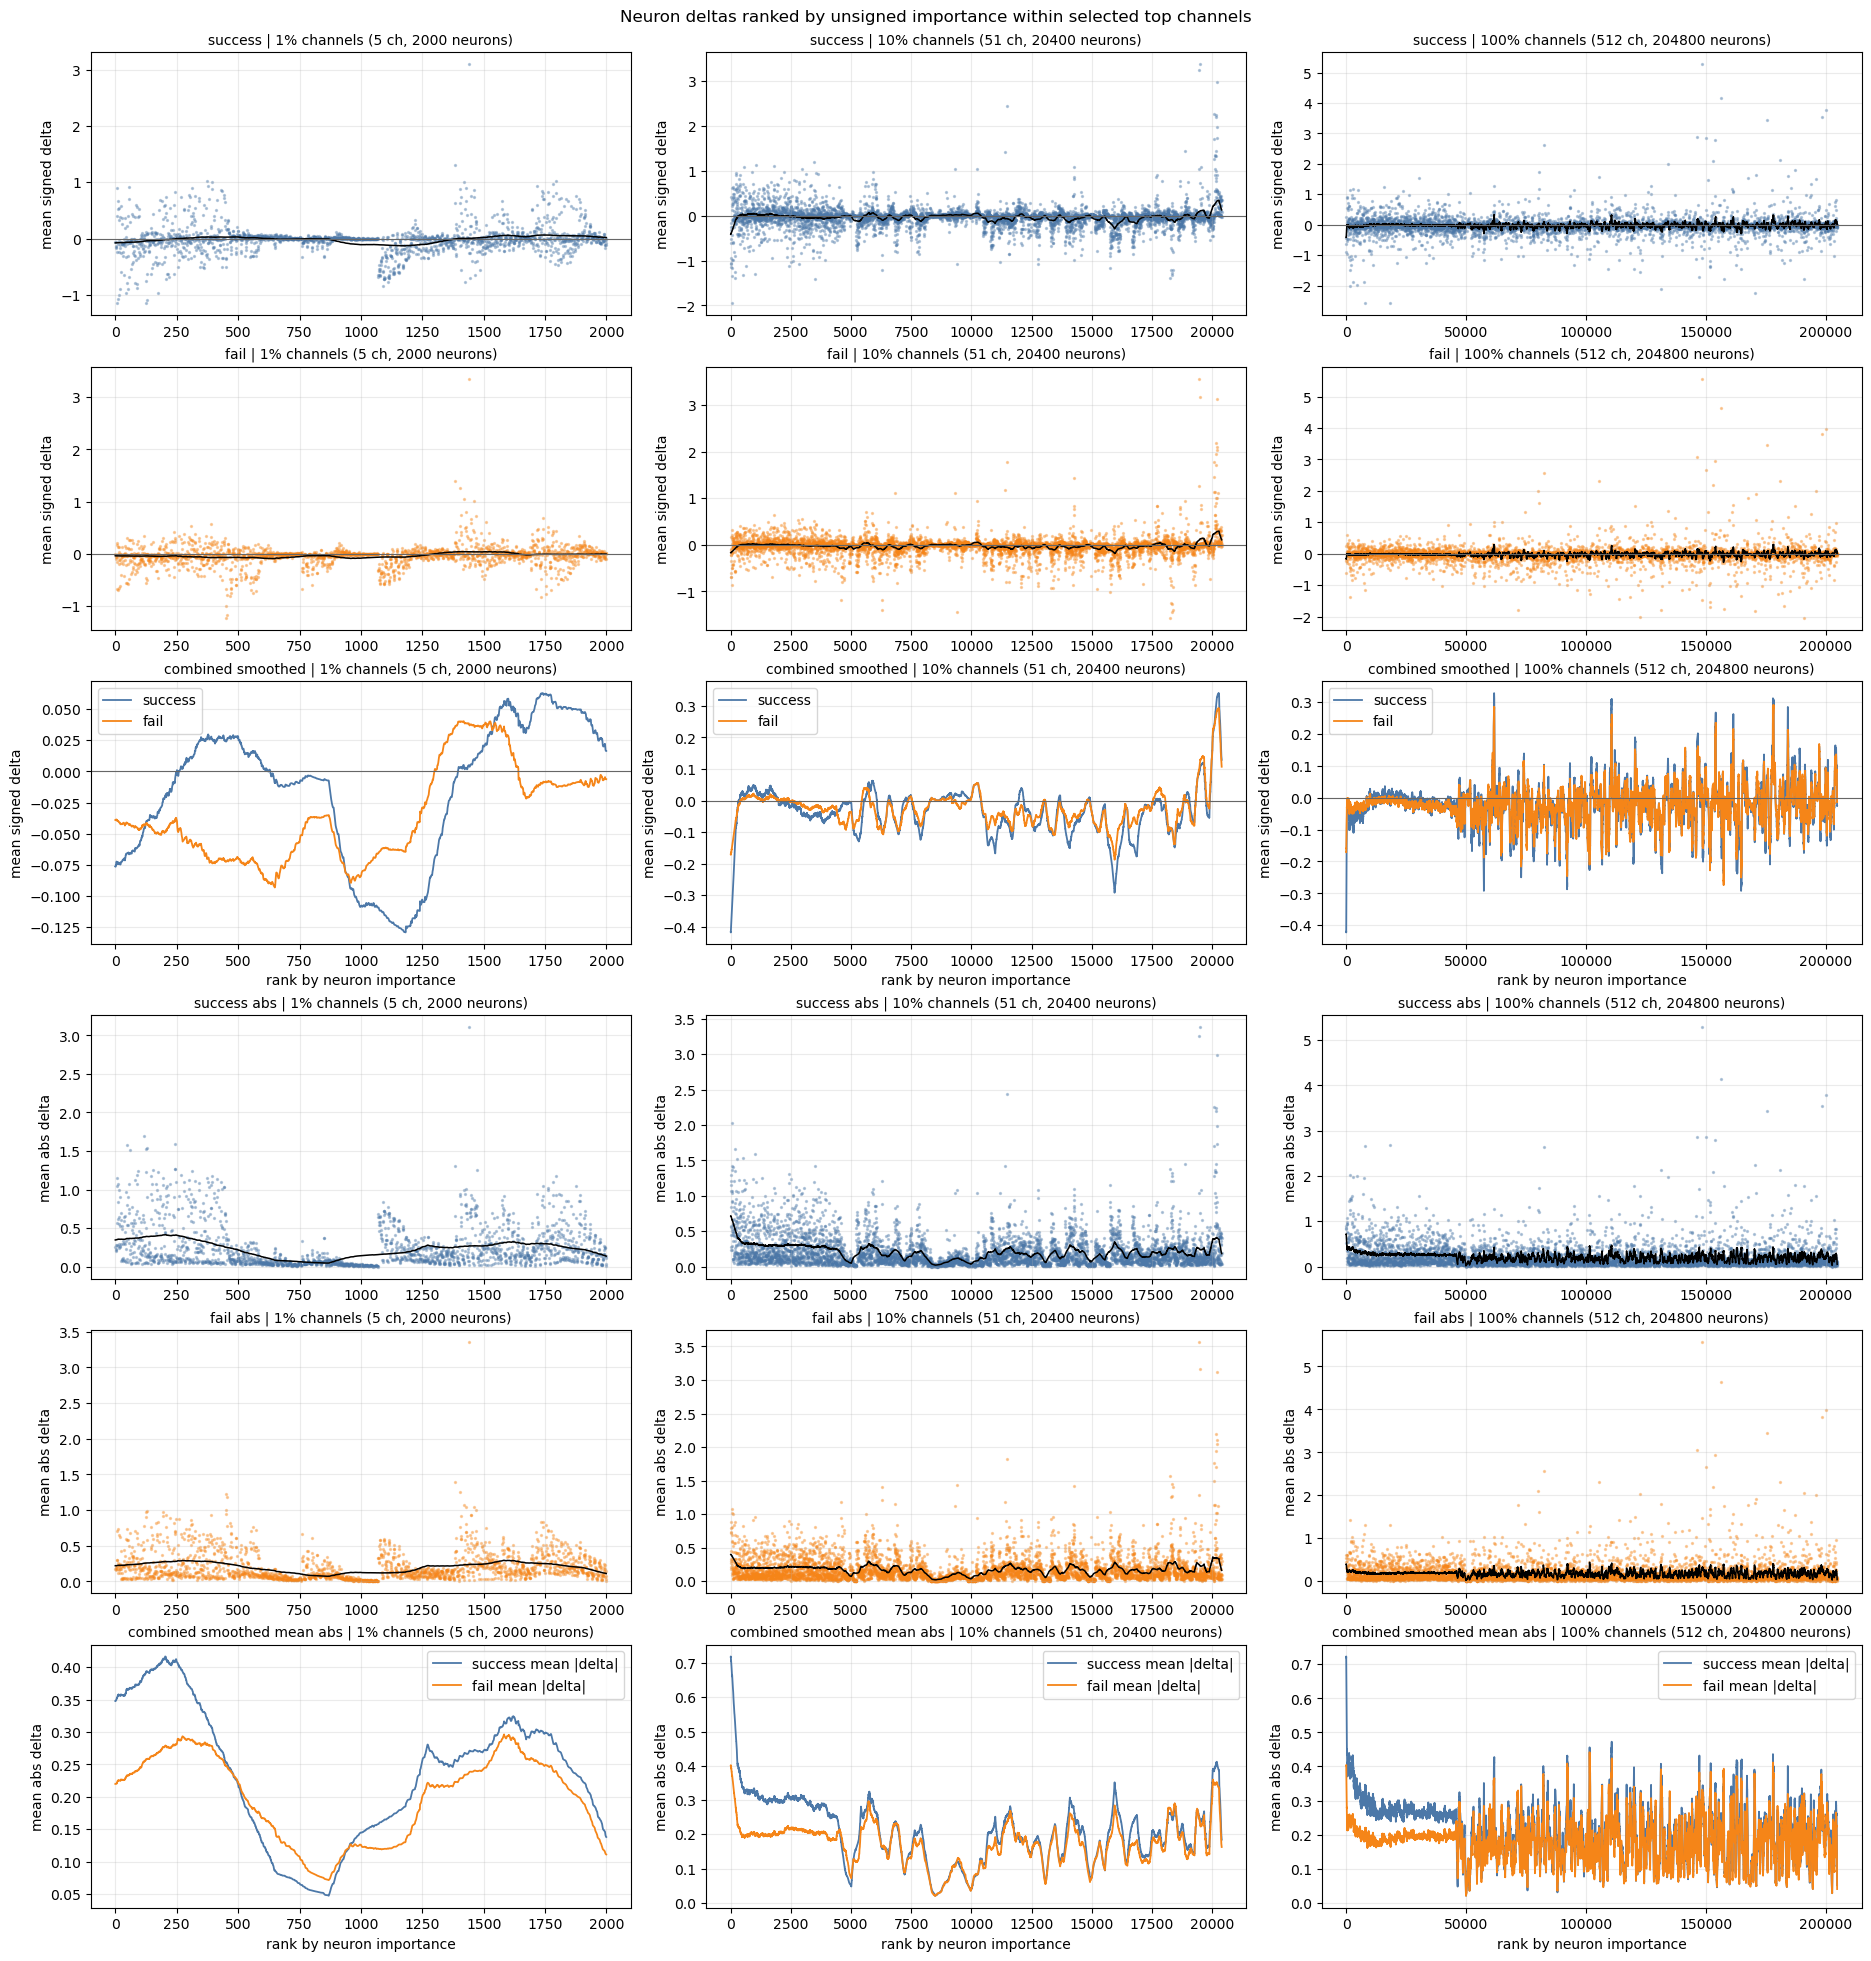

ranked neuron cache: new_experiments/outputs/patch_success_analysis/cache/ranked_neuron_delta_abs_v2_7dd953ff54a82f2a.pkl
loaded_from_cache=True
new_experiments/outputs/patch_success_analysis/figures/ranked_neuron_delta_top_channels_model_22.png


In [6]:
import importlib
import patch_success_analysis.channel_metrics as channel_metrics

channel_metrics = importlib.reload(channel_metrics)

channel_fractions = (1, 10, 100)
force_ranked_neuron_delta_recompute = False

ranked_result = channel_metrics.compute_or_load_ranked_neuron_delta_by_channel_fraction(
    exp,
    summary,
    selected_examples,
    fractions=channel_fractions,
    force=force_ranked_neuron_delta_recompute,
)
fig = channel_metrics.plot_ranked_neuron_delta_by_channel_fraction(ranked_result["ranked"], smooth_window=401)
ranked_fig_path = exp.figures_dir / "ranked_neuron_delta_top_channels_model_22.png"
fig.savefig(ranked_fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"ranked neuron cache: {ranked_result['cache_path']}")
print(f"loaded_from_cache={ranked_result['loaded_from_cache']}")
print(ranked_fig_path)
